# Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from cycler import cycler

# Higher-resolution plotting for clearer notebook figures.
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 180
plt.rcParams['savefig.dpi'] = 300

# Fixed color palette
PALETTE = ['#04CB93', '#E79F00', '#FE6F93', '#0072B3', '#C3C3C3', '#000000']
plt.rcParams['axes.prop_cycle'] = cycler(color=PALETTE)

FIGURE_DIR = Path('notebook/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['lines.linewidth'] = 2.6
plt.rcParams['lines.markersize'] = 10


# Helpers


In [2]:
def register_error_exponent(n_logical, T_arch, T2_limit):
    return n_logical * T_arch / T2_limit


def overhead(m, x):
    return m * x


## Surface-code helpers


### Surface-code logical-lifetime anchors

The surface-code comparison treats the quoted distance-3 logical lifetime as the anchor for the conservative suppression factor $\Lambda=2$ only. For a different suppression factor, the distance-3 anchor is recalculated from the standard scaling of logical error per cycle,

$\epsilon_d \propto (p/p_\mathrm{thr})^{(d+1)/2} = \Lambda^{-(d+1)/2}$.

Since logical lifetime is inversely proportional to logical error rate, the distance-3 lifetime for a new $\Lambda$ is

$T_{3}(\Lambda) = T_{3}(\Lambda_0) (\Lambda/\Lambda_0)^2$, with $\Lambda_0=2$.

The lifetime at general distance is then

$T_d(\Lambda) = T_3(\Lambda) \Lambda^{(d-3)/2}$.

This avoids forcing all $\Lambda$ traces to share the same distance-3 point; stronger suppression factors also imply a better distance-3 logical lifetime under the same scaling law.


In [3]:
magic_space_overhead_factor = 1
compilation_space_overhead_factor = 1


def surface_code_n_memory(distance):
    return 2 * distance**2 - 1


def surface_code_n_overhead(distance):
    n_memory = surface_code_n_memory(distance)
    return n_memory * magic_space_overhead_factor * compilation_space_overhead_factor


def surface_code_T(T_gate_count, distance, t_cycle):
    return T_gate_count * distance * t_cycle


def surface_code_Tlogical(distance, Lambda, Tlogical_3, reference_Lambda=2):
    Tlogical_3_for_Lambda = Tlogical_3 * (Lambda / reference_Lambda)**2
    return Tlogical_3_for_Lambda * Lambda**((distance - 3) / 2)


## Exponent-based comparison

This plot uses a cumulative register error exponent $H$ on the x-axis and keeps the register failure probability $P_\mathrm{fail}=1-e^{-H}$ as the top-axis interpretation. The benchmark is specified by dimensionless angular analog evolution time $Jt$. Here a 25 ns interaction time means one full $2\pi$ rotation, so the physical time per unit $Jt$ is $25\,\mathrm{ns}/2\pi$. Raw and EPS use this physical analog time, while surface code and STAR use an optimistic edge-colored Trotterization of the same $Jt$.

All analog and logical-lifetime exponents use an effective transverse coherence time $T_2$ in $H=nT_\mathrm{err}/T_2$. In the raw analog case this $T_2$ is dominated by pure dephasing, so we label the swept parameter as $T_\phi$. In the EPS case pure dephasing is assumed to be removed, so the limiting value is $T_2=2T_1$ and the plotted EPS labels quote the corresponding $T_1$.

For the surface-code baseline, the time factor is circuit depth, not total T count: T gates on different edges/registers are parallelized into edge-color and synthesis-depth layers. The total T count is used only to size an optimistic magic-state factory area, with no routing overhead or factory-induced stalls. STAR is plotted as a partial-FTQC literature baseline: it keeps the same Trotterized Pauli-rotation structure as the surface-code branch, but directly implements arbitrary rotations through injected analog-rotation states instead of Clifford+T synthesis and magic-state distillation. Its plotted exponent is $H_\mathrm{STAR}=H_\mathrm{rot}+H_\mathrm{Cliff}$, with $H_\mathrm{rot}=N_\mathrm{rot}/N_\mathrm{rot,budget}$ and $N_\mathrm{rot,budget}=1/[2(2p/15)]$ matching the STAR paper's two-RUS-step average. The Clifford term uses the paper's fitted logical-round scaling for $d=3,5,7,9$ as a sensitivity estimate, and we show STAR traces for $p=5\times10^{-5}$, $p=10^{-4}$, and $p=5\times10^{-4}$. All STAR points use the same 50-site benchmark; the d=9 point therefore extrapolates beyond the paper's $10^4$-physical-qubit anchor.


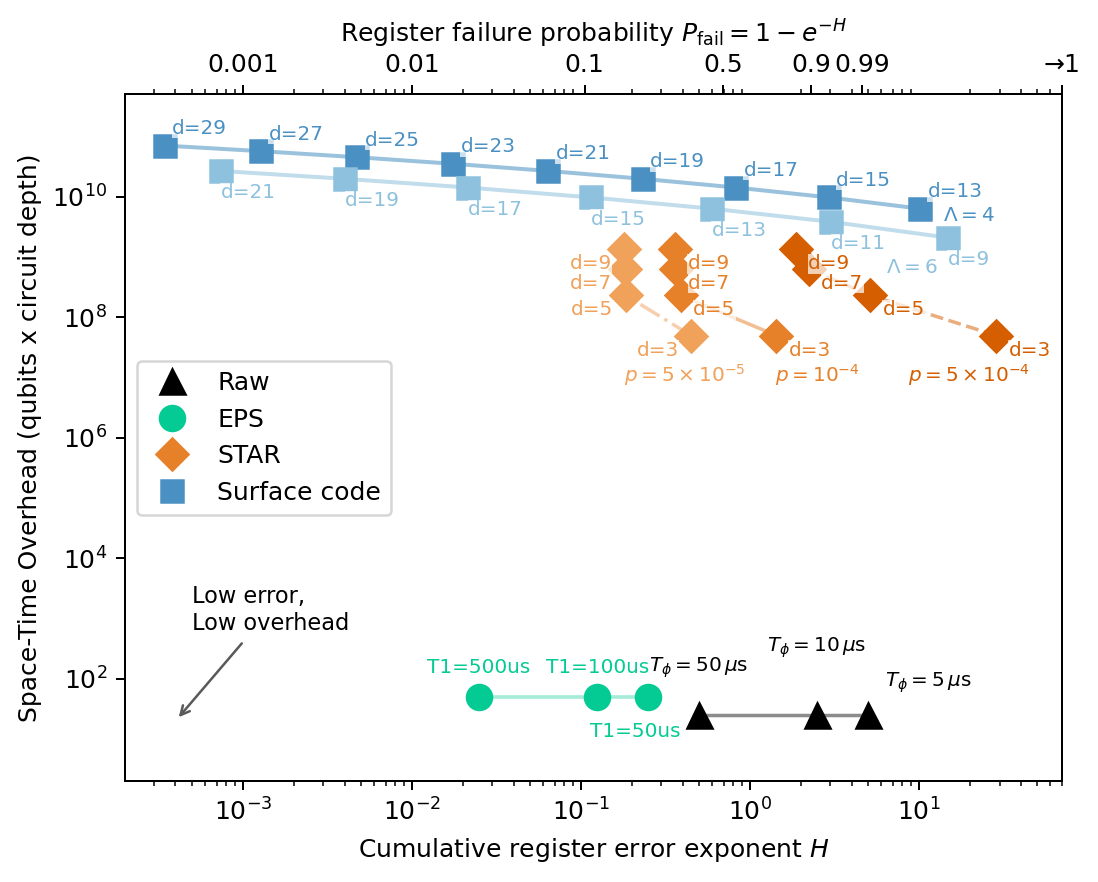

[{'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw $T_\\phi=5\\,\\mu\\mathrm{s}$',
  'H': 5.0,
  'P_fail': 0.9932620530009145,
  'nT': 25.0,
  'marker': '^',
  'color': '#000000'},
 {'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw $T_\\phi=10\\,\\mu\\mathrm{s}$',
  'H': 2.5,
  'P_fail': 0.9179150013761012,
  'nT': 25.0,
  'marker': '^',
  'color': '#000000'},
 {'scheme': 'Raw',
  'group': 'Raw',
  'label': 'Raw $T_\\phi=50\\,\\mu\\mathrm{s}$',
  'H': 0.5,
  'P_fail': 0.3934693402873666,
  'nT': 25.0,
  'marker': '^',
  'color': '#000000'},
 {'scheme': 'EPS',
  'group': 'EPS',
  'label': 'EPS T1=50us',
  'H': 0.25,
  'P_fail': 0.22119921692859512,
  'nT': 50.0,
  'marker': 'o',
  'color': '#04CB93'},
 {'scheme': 'EPS',
  'group': 'EPS',
  'label': 'EPS T1=100us',
  'H': 0.125,
  'P_fail': 0.11750309741540454,
  'nT': 50.0,
  'marker': 'o',
  'color': '#04CB93'},
 {'scheme': 'EPS',
  'group': 'EPS',
  'label': 'EPS T1=500us',
  'H': 0.025,
  'P_fail': 0.024690087971667385,
  'nT': 5

In [4]:
# Resource overhead and coherence conventions for the comparison point.
m_n_raw = 1
m_T_raw = 1
m_n_eps = 2
T2_surface_3 = 100  # d=3 logical T2 anchor for Lambda=2
marker_by_scheme = {'surface': 's', 'eps': 'o', 'raw': '^'}

comparison_n = 50
comparison_Jt = 20 * 2 * np.pi
# A 25 ns interaction time is taken to mean one full 2*pi rotation.
# The dimensionless Jt used here is angular phase, so t = (Jt / 2*pi) * T_2pi.
J_full_rotation_time_us = 25e-3
Jt_time_unit_us = J_full_rotation_time_us / (2 * np.pi)
comparison_T = comparison_Jt * Jt_time_unit_us

# Optimistic digital baseline for a 5 x 10 nearest-neighbor 2D XY model.
# Each XY edge is decomposed into XX and YY Pauli rotations. Edge coloring
# sets the circuit depth; the total edge count sets only the T-count and factory demand.
surface_lattice_shape = (5, 10)
surface_n_edges = surface_lattice_shape[0] * (surface_lattice_shape[1] - 1) + surface_lattice_shape[1] * (surface_lattice_shape[0] - 1)
surface_edge_color_depth = 4
surface_xy_pauli_rotations_per_edge = 2
surface_T_depth_per_arbitrary_rotation = 10
surface_trotter_step_Jt = np.pi / 2
surface_n_trotter_steps = int(np.ceil(comparison_Jt / surface_trotter_step_Jt))
surface_T_depth = surface_n_trotter_steps * surface_edge_color_depth * surface_xy_pauli_rotations_per_edge * surface_T_depth_per_arbitrary_rotation
surface_T_count = surface_n_trotter_steps * surface_n_edges * surface_xy_pauli_rotations_per_edge * surface_T_depth_per_arbitrary_rotation
surface_parallel_T_demand = int(np.ceil(surface_T_count / surface_T_depth))

# Aggressively optimistic factory model: enough factories supply the average
# parallel T-state demand without increasing the circuit depth.
surface_T_factory_patch_equivalents = 8
surface_T_factory_count = surface_parallel_T_demand
surface_comparison_candidate_distances = list(range(3, 82, 2))
surface_comparison_Lambda_values = [4, 6]
surface_min_H = 1e-3
surface_max_H = -np.log1p(-0.9999999)
raw_comparison_T_phi_values = [5, 10, 50]
eps_comparison_T2_values = [100, 200, 1_000]

xlim = (-np.log1p(-0.0002), 70)
ylim = (2, 5e11)
annotation_fontsize = 8
raw_comparison_color = '#000000'
eps_comparison_color = '#04CB93'
surface_comparison_colors = {2: '#0072B3', 4: '#4A90C2', 6: '#8EC1DD'}
surface_line_styles = {2: '-', 4: '-', 6: '-'}
star_comparison_colors = {5e-5: '#F0A15A', 1e-4: '#E6812A', 5e-4: '#D55E00'}
star_line_styles = {5e-5: '-.', 1e-4: '-', 5e-4: '--'}
star_marker = 'D'

comparison_points = []
eps_annotation_offsets = {
    'EPS T1=50us': (-5, -10),
    'EPS T1=100us': (0, 8),
    'EPS T1=500us': (0, 8),
}
raw_annotation_offsets = {
    r'Raw $T_\phi=5\,\mu\mathrm{s}$': (24, 8),
    r'Raw $T_\phi=10\,\mu\mathrm{s}$': (0, 22),
    r'Raw $T_\phi=50\,\mu\mathrm{s}$': (0, 14),
}
surface_distance_labels = None
lambda_label_distance = 3
star_annotation_offsets = {3: (5, -2), 5: (5, -2), 7: (5, -2), 9: (5, -2)}
star_annotation_offsets_by_p = {5e-5: {3: (-5, -2), 5: (-5, -2), 7: (-5, -2), 9: (-5, -2)}}
star_p_labels = {5e-5: r'$p=5\times10^{-5}$', 1e-4: r'$p=10^{-4}$', 5e-4: r'$p=5\times10^{-4}$'}
star_p_label_offsets = {5e-5: (0, -45), 1e-4: (40, -45), 5e-4: (45, -45)}
surface_distance_label_offsets = {
    2: (4, 2),
    4: (3, 3),
    6: (0, -5),
}
label_bbox = dict(facecolor='white', edgecolor='none', alpha=0.72, pad=0.15)
lambda_label_offsets = {
    2: (30, 0),
    4: (30, 1),
    6: (-4, -8),
}

def add_comparison_point(scheme, label, H, nT, marker, color, group=None, **extra):
    point = {
        'scheme': scheme,
        'group': group or scheme,
        'label': label,
        'H': H,
        'P_fail': 1 - np.exp(-H),
        'nT': nT,
        'marker': marker,
        'color': color,
    }
    point.update(extra)
    comparison_points.append(point)

nT_raw = overhead(m_n_raw, comparison_n) * overhead(m_T_raw, comparison_T)
for T_phi_raw_comp in raw_comparison_T_phi_values:
    T2_raw_comp = T_phi_raw_comp
    H_raw = register_error_exponent(comparison_n, overhead(m_T_raw, comparison_T), T2_raw_comp)
    add_comparison_point('Raw', rf'Raw $T_\phi={T_phi_raw_comp:g}\,\mu\mathrm{{s}}$', H_raw, nT_raw, '^', raw_comparison_color)

for T2_eps in eps_comparison_T2_values:
    H_eps = register_error_exponent(comparison_n, comparison_T, T2_eps)
    nT_eps = overhead(m_n_eps, comparison_n) * comparison_T
    add_comparison_point(
        'EPS',
        f'EPS T1={T2_eps / 2:g}us',
        H_eps,
        nT_eps,
        marker_by_scheme['eps'],
        eps_comparison_color,
    )

# STAR partial-FTQC reference points from Akahoshi et al. STAR still uses
# Trotterized Pauli rotations, but replaces Clifford+T synthesis of each
# arbitrary rotation with direct analog rotation via injected ancilla states.
# The plotted exponent includes the distance-independent rotation-injection
# term and a distance-dependent Clifford logical-round sensitivity term.
star_rotation_latency_clocks = 18
star_distances = [3, 5, 7, 9]
star_physical_error_rates = [5e-5, 1e-4, 5e-4]
star_clifford_fit = {
    'C_Z': 0.0679,
    'p_th_Z': 0.00385,
    'C_X': 0.0819,
    'p_th_X': 0.00416,
}
star_rotation_depth = (
    surface_n_trotter_steps
    * surface_edge_color_depth
    * surface_xy_pauli_rotations_per_edge
    * star_rotation_latency_clocks
)

def lattice_edge_count(lattice_shape):
    n_rows, n_cols = lattice_shape
    return n_rows * (n_cols - 1) + n_cols * (n_rows - 1)

def star_rotation_count(lattice_shape):
    return surface_n_trotter_steps * lattice_edge_count(lattice_shape) * surface_xy_pauli_rotations_per_edge

def star_compact_physical_qubits(n_logical, distance):
    return (1.5 * n_logical + 5) * 2 * distance**2

def star_clifford_error_per_clock(distance, p_phys):
    exponent = (distance + 1) / 2
    P_Z = star_clifford_fit['C_Z'] * (p_phys / star_clifford_fit['p_th_Z'])**exponent
    P_X = star_clifford_fit['C_X'] * (p_phys / star_clifford_fit['p_th_X'])**exponent
    return P_Z + P_X

def add_star_point(label, distance, p_phys, n_logical, n_phys, lattice_shape):
    n_edges = lattice_edge_count(lattice_shape)
    N_rot_star = star_rotation_count(lattice_shape)
    P_rot_star = 2 * p_phys / 15
    N_rotation_budget_star = 1 / (2 * P_rot_star)
    H_rotation_star = N_rot_star / N_rotation_budget_star
    N_clifford_clock_star = star_rotation_depth
    P_clifford_clock_star = star_clifford_error_per_clock(distance, p_phys)
    H_clifford_star = N_clifford_clock_star * P_clifford_clock_star
    H_star = H_rotation_star + H_clifford_star
    T_depth_star = star_rotation_depth * distance
    nT_star = n_phys * T_depth_star
    add_comparison_point(
        'STAR',
        label,
        H_star,
        nT_star,
        star_marker,
        star_comparison_colors[p_phys],
        group=f'STAR p={p_phys:g}',
        d=distance,
        p_phys=p_phys,
        n_logical=n_logical,
        n_active_lattice_sites=lattice_shape[0] * lattice_shape[1],
        lattice_shape=lattice_shape,
        n_edges=n_edges,
        n_phys=n_phys,
        N_rot=N_rot_star,
        N_rotation_budget=N_rotation_budget_star,
        H_rotation=H_rotation_star,
        N_clifford_clock=N_clifford_clock_star,
        P_clifford_clock=P_clifford_clock_star,
        H_clifford=H_clifford_star,
        P_rot=P_rot_star,
        rotation_depth=star_rotation_depth,
        T_depth=T_depth_star,
    )

for star_p_phys in star_physical_error_rates:
    for star_distance in star_distances:
        add_star_point(
            f'd={star_distance}',
            star_distance,
            star_p_phys,
            comparison_n,
            star_compact_physical_qubits(comparison_n, star_distance),
            surface_lattice_shape,
        )

def optimistic_T_factory_area(distance):
    return surface_T_factory_count * surface_T_factory_patch_equivalents * surface_code_n_memory(distance)

for Lambda_surface in surface_comparison_Lambda_values:
    surface_distances_for_Lambda = [
        d for d in surface_comparison_candidate_distances
        if Lambda_surface != 2 or (d - 3) % 4 == 0
    ]
    for d in surface_distances_for_Lambda:
        # Runtime uses circuit depth only; total T count is not serialized.
        T_surface = surface_code_T(surface_T_depth, d, 1)
        T2_surface = surface_code_Tlogical(d, Lambda_surface, T2_surface_3)
        n_surface_memory = surface_code_n_overhead(d) * comparison_n
        n_surface_factory = optimistic_T_factory_area(d)
        n_surface = n_surface_memory + n_surface_factory
        H_surface = register_error_exponent(comparison_n, T_surface, T2_surface)
        nT_surface = n_surface * T_surface
        if H_surface <= surface_max_H:
            add_comparison_point(
                'Surface code',
                f'd={d}',
                H_surface,
                nT_surface,
                marker_by_scheme['surface'],
                surface_comparison_colors[Lambda_surface],
                group=f'Surface code Lambda={Lambda_surface}',
                Lambda=Lambda_surface,
                d=d,
                n_memory=n_surface_memory,
                n_factory=n_surface_factory,
                T_depth=surface_T_depth,
                T_count=surface_T_count,
            )
        if H_surface <= surface_min_H:
            break

fig, ax = plt.subplots(figsize=(6.2, 5.0))

# Raw trace.
raw_points = [point for point in comparison_points if point['scheme'] == 'Raw']
ax.plot(
    [point['H'] for point in raw_points],
    [point['nT'] for point in raw_points],
    '-',
    color=raw_comparison_color,
    alpha=0.45,
    linewidth=1.4,
)
for point_index, point in enumerate(raw_points):
    ax.plot(point['H'], point['nT'], '^', color=raw_comparison_color, markersize=10, label='Raw' if point_index == 0 else None)
    raw_offset = raw_annotation_offsets[point['label']]
    ax.annotate(
        point['label'].replace('Raw ', ''),
        (point['H'], point['nT']),
        textcoords='offset points',
        xytext=raw_offset,
        ha='center',
        va='bottom' if raw_offset[1] > 0 else 'top',
        fontsize=annotation_fontsize,
        color=raw_comparison_color,
    )

# EPS trace.
eps_points = [point for point in comparison_points if point['scheme'] == 'EPS']
ax.plot(
    [point['H'] for point in eps_points],
    [point['nT'] for point in eps_points],
    '-',
    color=eps_comparison_color,
    alpha=0.35,
    linewidth=1.5,
)
for point_index, point in enumerate(eps_points):
    ax.plot(point['H'], point['nT'], marker_by_scheme['eps'], color=eps_comparison_color, markersize=10, label='EPS' if point_index == 0 else None)
    offset = eps_annotation_offsets[point['label']]
    ax.annotate(
        point['label'].replace('EPS ', ''),
        (point['H'], point['nT']),
        textcoords='offset points',
        xytext=offset,
        ha='center',
        va='bottom' if offset[1] > 0 else 'top',
        fontsize=annotation_fontsize,
        color=eps_comparison_color,
    )

# STAR partial-FTQC reference points.
for star_p_phys in star_physical_error_rates:
    star_points = [point for point in comparison_points if point['group'] == f'STAR p={star_p_phys:g}']
    ax.plot(
        [point['H'] for point in star_points],
        [point['nT'] for point in star_points],
        linestyle=star_line_styles[star_p_phys],
        color=star_comparison_colors[star_p_phys],
        alpha=0.5,
        linewidth=1.4,
    )
    for point_index, point in enumerate(star_points):
        ax.plot(
            point['H'],
            point['nT'],
            star_marker,
            color=star_comparison_colors[star_p_phys],
            markersize=9,
            label='STAR' if star_p_phys == 1e-4 and point_index == 0 else None,
        )
        offset = star_annotation_offsets_by_p.get(star_p_phys, star_annotation_offsets)[point['d']]
        ax.annotate(
            point['label'],
            (point['H'], point['nT']),
            textcoords='offset points',
            xytext=offset,
            ha='right' if offset[0] < 0 else 'left',
            va='bottom' if offset[1] >= 0 else 'top',
            fontsize=annotation_fontsize,
            color=star_comparison_colors[star_p_phys],
            bbox=label_bbox,
        )
    label_point = star_points[-1]
    p_offset = star_p_label_offsets[star_p_phys]
    ax.annotate(
        star_p_labels[star_p_phys],
        (label_point['H'], label_point['nT']),
        textcoords='offset points',
        xytext=p_offset,
        ha='right' if p_offset[0] < 0 else 'left',
        va='bottom' if p_offset[1] >= 0 else 'top',
        fontsize=annotation_fontsize,
        color=star_comparison_colors[star_p_phys],
        bbox=label_bbox,
    )

# Surface-code sensitivity traces.
for Lambda_surface in surface_comparison_Lambda_values:
    points = [point for point in comparison_points if point['group'] == f'Surface code Lambda={Lambda_surface}']
    ax.plot(
        [point['H'] for point in points],
        [point['nT'] for point in points],
        linestyle=surface_line_styles[Lambda_surface],
        color=surface_comparison_colors[Lambda_surface],
        alpha=0.55,
        linewidth=1.6,
    )
    for point_index, point in enumerate(points):
        ax.plot(
            point['H'],
            point['nT'],
            marker_by_scheme['surface'],
            color=surface_comparison_colors[Lambda_surface],
            alpha=1.0,
            markersize=9,
            label='Surface code' if Lambda_surface == 4 and point_index == 0 else None,
        )
        if xlim[0] <= point['H'] <= xlim[1]:
            distance_offset = surface_distance_label_offsets[Lambda_surface]
            ax.annotate(
                point['label'],
                (point['H'], point['nT']),
                textcoords='offset points',
                xytext=distance_offset,
                ha='left' if distance_offset[0] >= 0 else 'right',
                va='bottom' if distance_offset[1] >= 0 else 'top',
                fontsize=annotation_fontsize,
                color=point['color'],
                bbox=label_bbox,
            )

    visible_lambda_points = [point for point in points if xlim[0] <= point['H'] <= xlim[1]]
    lambda_label_point = next(
        (point for point in visible_lambda_points if point['d'] == lambda_label_distance),
        visible_lambda_points[0] if visible_lambda_points else points[0],
    )
    ax.annotate(
        rf'$\Lambda={Lambda_surface}$',
        (lambda_label_point['H'], lambda_label_point['nT']),
        textcoords='offset points',
        xytext=lambda_label_offsets[Lambda_surface],
        ha='right',
        va='top',
        fontsize=annotation_fontsize,
        color=surface_comparison_colors[Lambda_surface],
        bbox=label_bbox,
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.margins(x=0.04, y=0.08)
ax.set_xlabel(r'Cumulative register error exponent $H$')
ax.set_ylabel('Space-Time Overhead (qubits x circuit depth)')
ax.annotate(
    'Low error,\nLow overhead',
    xy=(4e-4, 0.2e2),
    xytext=(0.5e-3, 1.4e3),
    arrowprops=dict(arrowstyle='->', color='0.35', lw=1.0),
    color='k',
    fontsize=9,
    ha='left',
    va='center',
)
ax.legend(loc='center left', frameon=True)

ax_top = ax.twiny()
ax_top.set_xscale('log')
ax_top.set_xlim(ax.get_xlim())
pfail_ticks = np.array([1e-3, 1e-2, 1e-1, 0.5, 0.9, 0.99])
H_ticks = -np.log1p(-pfail_ticks)
visible = (H_ticks >= ax.get_xlim()[0]) & (H_ticks <= ax.get_xlim()[1])
top_tick_positions = list(H_ticks[visible])
top_tick_labels = [f'{tick:g}' for tick in pfail_ticks[visible]]
if top_tick_positions[-1] < ax.get_xlim()[1]:
    top_tick_positions.append(ax.get_xlim()[1])
    top_tick_labels.append(r'$\to 1$')
ax_top.set_xticks(top_tick_positions)
ax_top.set_xticklabels(top_tick_labels)
ax_top.xaxis.set_minor_formatter(plt.NullFormatter())
ax_top.set_xlabel(r'Register failure probability $P_\mathrm{fail}=1-e^{-H}$')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'joint_space_time_error_exponent.pdf', format='pdf', bbox_inches='tight')
plt.show()

comparison_points
